### Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.stats as stats

# Scikit-Learn: Core Workflow
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

### Load Data

In [2]:
REPO_DIR = Path("..")
DATA_DIR = REPO_DIR / "Data"

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv", index_col=0).squeeze("columns")

### Create Ridge Pipline & Analysis 

### Pipline for Ridge Regression 

`scikit-learn` is used to construct a Ridge Regression pipeline that integrates data preprocessing and model training into a single workflow. The `Pipeline` sequentially applies `SimpleImputer` to handle missing values using the median, followed by `StandardScaler` to standardize features via Z-score normalization, and finally fits a `Ridge` regression model, which adds L2 regularization to reduce overfitting. To optimize the model, `GridSearchCV` is used with 5-fold cross-validation (`KFold`) to tune the regularization parameter (`alpha`) over a logarithmic grid. This approach systematically evaluates different levels of regularization, ensuring the selected model balances bias and variance while improving generalization performance on unseen data.


In [3]:
# 5-fold CV setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Alpha grid
param_grid = {
    'ridge__alpha': np.logspace(-4, 4, 100)
}

# GridSearch with 5-fold CV
ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_error'
)

# Fit model
ridge_cv.fit(X_train, y_train)

# Predictions
y_train_pred = ridge_cv.predict(X_train)
y_test_pred = ridge_cv.predict(X_test)

# Compute RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Best alpha:", ridge_cv.best_params_['ridge__alpha'])
print("RMSE:", rmse)
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test R^2:", r2_score(y_test, y_test_pred))



Best alpha: 138.48863713938746
RMSE: 0.13756093051356014
Train R^2: 0.6877321064002478
Test R^2: 0.6434112392890765


### CV Error vs Alpha

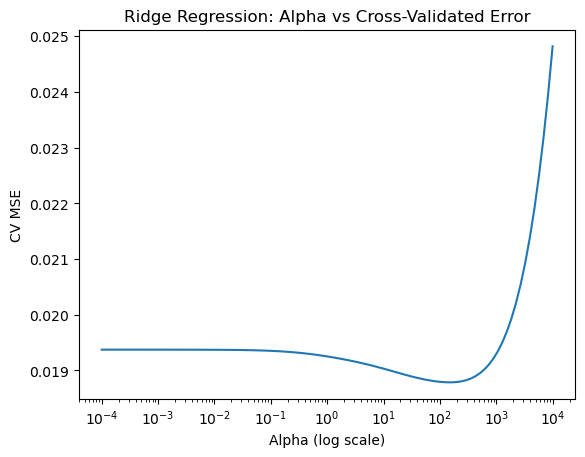

In [4]:
results = pd.DataFrame(ridge_cv.cv_results_)

plt.figure()
plt.plot(param_grid['ridge__alpha'], -results['mean_test_score'])
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("CV MSE")
plt.title("Ridge Regression: Alpha vs Cross-Validated Error")
plt.show()

### Top 20 Ridge Coefficients

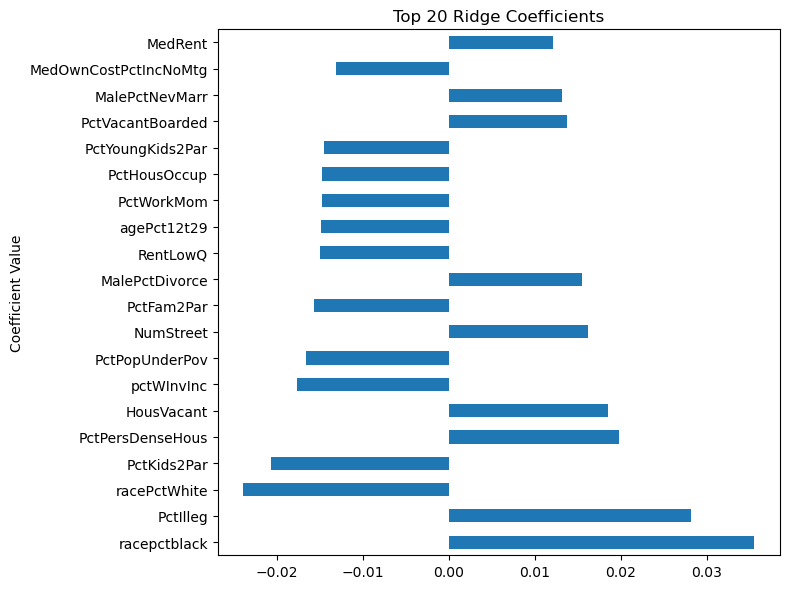

In [5]:
best_ridge = ridge_cv.best_estimator_.named_steps['ridge']

coef = pd.Series(best_ridge.coef_, index=X_train.columns)
top_coef = coef.sort_values(key=np.abs, ascending=False).head(20)

plt.figure(figsize=(8,6))
top_coef.plot(kind='barh')
plt.title("Top 20 Ridge Coefficients")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

# Diagnostic Plots

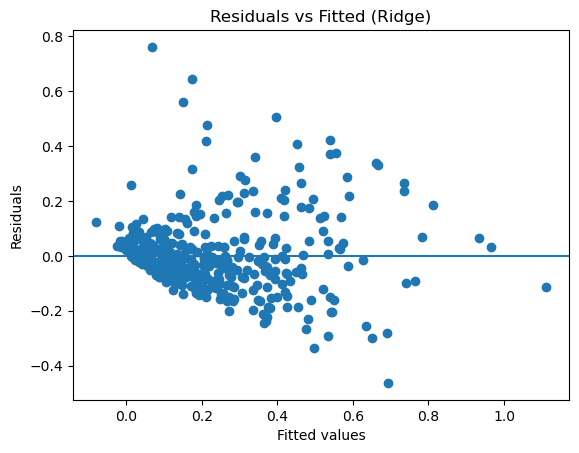

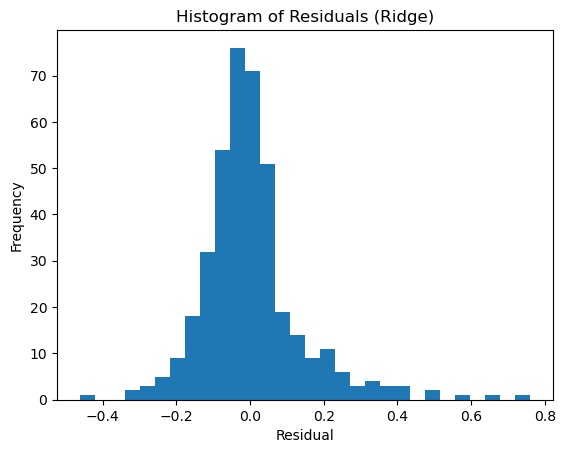

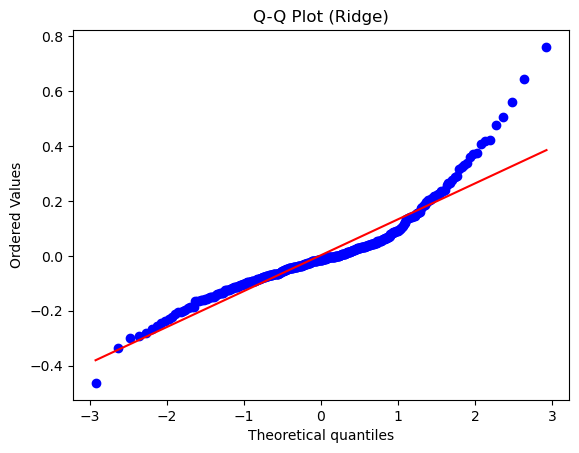

In [6]:


# Residuals from Ridge model
residuals = y_test - y_test_pred

# 1. Residuals vs Fitted (linearity & homoscedasticity)
plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Ridge)")
plt.show()

# 2. Histogram of residuals (distribution & skewness)
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals (Ridge)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# 3. Q-Q Plot (normality)
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot (Ridge)")
plt.show()

### Report

Ridge Regression was applied to the Communities and Crime dataset to predict violent crime rates by leveraging $L_2$ regularization to manage a large pool of correlated predictors. The model selection process utilized a **logarithmic scale** for the alpha hyperparameter—ranging from $10^{-4}$ to $10^4$—because the optimal penalty for a dataset can vary across several orders of magnitude. Using `np.logspace` ensures the search is efficient, covering both very small penalties (near-OLS) and very large penalties. The **Alpha vs. Cross-Validated Error plot** demonstrates this necessity, showing a clear "U-shaped" curve where the error is minimized at an **alpha of 138.49**. This relatively high alpha suggests that the dataset contains significant multicollinearity or "noise," requiring a stronger penalty to shrink the coefficients and ensure the model generalizes well. Consequently, the model achieved a stable fit with a **Training $R^2$ of 0.688** and a **Test $R^2$ of 0.643**, indicating that the regularization effectively prevented overfitting.


The impact of this regularization is visible in the **Top 20 Ridge Coefficients plot**, where the model identifies key socio-economic drivers while keeping their magnitudes in check. Variables reflecting family structure, such as the percentage of children in two-parent households (PctKids2Par), and demographic composition, such as the percentage of white residents (racePctWhite), were the strongest predictors of lower crime rates. Conversely, a higher percentage of black residents (racepctblack) and children born to never-married parents (PctIlleg) were associated with higher predicted crime. Specifically, the data shows that the percentage of the population that is black in these communities (averaging 17.9% in the raw UCI data) often correlates with other systemic socio-economic stressors. While the model provides a reasonably accurate baseline with an **RMSE of 0.1376**, diagnostic plots suggest underlying issues with the linear assumptions.

The **Residuals vs. Fitted plot** reveals a prominent "funnel" shape, indicating **heteroscedasticity** where the model's error variance increases at higher predicted crime levels. This is mirrored in the **Histogram of Residuals** and the **Q-Q Plot**, which both show a significant right-skew and heavy upper tail. These diagnostics confirm that while Ridge Regression successfully manages the high dimensionality of the data, the linear structure still struggles to account for the skewed distribution of crime rates. The model consistently underpredicts high-crime areas, suggesting that the relationship between these socio-economic predictors and violent crime may be non-linear or that the response variable requires a transformation to stabilize the variance and normalize the errors.